In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
data = pd.read_csv("student_marks.csv")

In [23]:
# Input and output
x = data[['Hours']]
y = data[['Marks']]

# Split dataset
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=1
)

# Train model
model = LinearRegression()
model.fit(x_train, y_train)
# Display accuracy
print("Training Accuracy:",
      round(model.score(x_train, y_train) * 100, 2))

print("Testing Accuracy:",
      round(model.score(x_test, y_test) * 100, 2))

# Predict marks for 11 study hours
new_data = pd.DataFrame([[11]], columns=["Hours"])
pred = model.predict(new_data)
print("Predicted Marks for 11 hours:", round(float(pred[0]), 2))


Training Accuracy: 98.24
Testing Accuracy: 98.2
Predicted Marks for 11 hours: 86.0


C:\Users\sachin\AppData\Local\Temp\ipykernel_9564\2718613355.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Predicted Marks for 11 hours:", round(float(pred[0]), 2))


In [30]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load MNIST-like digits dataset
digits = load_digits()

X = digits.data
labels = digits.target

# Function for binary classification
def classify_digit(digit):
    print("\n========== Digit", digit, "vs Not Digit", digit, "==========")

    y = (labels == digit)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=1
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    print("Training Accuracy:",
          round(model.score(X_train, y_train) * 100, 2))

    print("Testing Accuracy:",
          round(model.score(X_test, y_test) * 100, 2))

    prediction = model.predict([X_test[0]])

    if prediction[0]:
        print("First Test Sample: Digit is", digit)
    else:
        print("First Test Sample: Digit is not", digit)

    print("\nFirst 20 Predictions:")

    predictions = model.predict(X_test[:20])

    for i in range(20):
        if predictions[i]:
            print(f"Sample {i+1}: Digit is {digit}")
        else:
            print(f"Sample {i+1}: Digit is not {digit}")


# Q1: Digit 5 vs Not Digit 5
classify_digit(5)

# Q2: Digit 7 vs Not Digit 7
classify_digit(7)

# Q3: Digit 0 vs Not Digit 0
classify_digit(0)

# Q4: Digit 9 vs Not Digit 9
classify_digit(9)


========== Digit 5 vs Not Digit 5 ==========
Training Accuracy: 100.0
Testing Accuracy: 98.89
First Test Sample: Digit is not 5

First 20 Predictions:
Sample 1: Digit is not 5
Sample 2: Digit is 5
Sample 3: Digit is not 5
Sample 4: Digit is not 5
Sample 5: Digit is not 5
Sample 6: Digit is not 5
Sample 7: Digit is not 5
Sample 8: Digit is not 5
Sample 9: Digit is 5
Sample 10: Digit is not 5
Sample 11: Digit is not 5
Sample 12: Digit is not 5
Sample 13: Digit is not 5
Sample 14: Digit is not 5
Sample 15: Digit is not 5
Sample 16: Digit is not 5
Sample 17: Digit is not 5
Sample 18: Digit is not 5
Sample 19: Digit is not 5
Sample 20: Digit is not 5

========== Digit 7 vs Not Digit 7 ==========
Training Accuracy: 100.0
Testing Accuracy: 99.07
First Test Sample: Digit is not 7

First 20 Predictions:
Sample 1: Digit is not 7
Sample 2: Digit is not 7
Sample 3: Digit is not 7
Sample 4: Digit is 7
Sample 5: Digit is not 7
Sample 6: Digit is not 7
Sample 7: Digit is not 7
Sample 8: Digit is not

First Five Records:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value  
0         322         126         8.3252              452600  
1        2401        1138         8.3014              358500  
2         496         177         7.2574              352100  
3         558         219         5.6431              341300  
4         565         259         3.8462              342200  

Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
popu

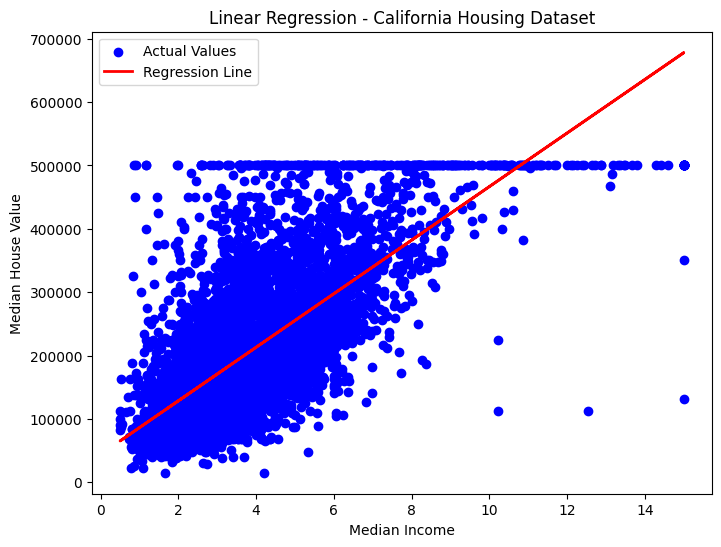


Interpretation:
The regression model predicts median house value using median income.
A higher R2 score indicates a better fit of the regression model.


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Load the dataset
data = pd.read_csv("housing.csv")

# 2. Display first five records
print("First Five Records:")
print(data.head())

# 3. Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# 4. Select Median Income as independent variable
X = data[['median_income']]

# Target variable
y = data['median_house_value']

# 5. Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# 6. Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 7. Predict house prices
y_pred = model.predict(X_test)

# 8. Display Coefficient, Intercept and R2 Score
print("\nCoefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R2 Score:", round(r2_score(y_test, y_pred), 2))

# 9. Plot Regression Line
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='blue', label='Actual Values')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Linear Regression - California Housing Dataset")
plt.legend()
plt.show()

# 10. Interpretation
print("\nInterpretation:")
print("The regression model predicts median house value using median income.")
print("A higher R2 score indicates a better fit of the regression model.")